# SliceLab — Segmentation de pizzerias par K-Means

**Objectif :** Consolider 5 exports régionaux hétérogènes, explorer les données, et appliquer un clustering K-Means (k=2) pour identifier des profils d'établissements.

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

DATA_DIR = "data/"

# Colonnes cibles apres consolidation
COLONNES = [
    "latitude", "longitude", "type_etablissement",
    "nb_pizzas_carte", "prix_moyen", "note_moyenne",
    "nb_avis", "temps_preparation_moyen",
    "annee_ouverture", "ca_mensuel_k"
]

---
## 1. Chargement et consolidation des donnees

### 1.1 Nord-Ouest

**Problemes connus :**
- 2 lignes de commentaires en tete (`# Export...`)
- Separateur `;`
- Decimales avec `,` (lat, lon, note)
- Prix au format `"9,9 euros"` -> retirer le symbole, remplacer `,` par `.`
- Valeurs manquantes : chaines vides, `N/A`, `non renseigne`

In [2]:
# charger donnees_nord_ouest.csv
df_no = pd.read_csv(
    DATA_DIR + "donnees_nord_ouest.csv",
    sep=";",
    decimal=",",
    comment="#",
    na_values=["", "N/A", "non renseigne", "NC", "Non communiqué"],
)

# Nettoyage des noms de colonnes (espaces parasites)
df_no.columns = df_no.columns.str.strip()

# renommer les colonnes pour correspondre a COLONNES
df_no = df_no.rename(columns={
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Type": "type_etablissement",
    "Nb pizzas carte": "nb_pizzas_carte",
    "Prix moyen": "prix_moyen",
    "Note moyenne": "note_moyenne",
    "Nb avis": "nb_avis",
    "Temps préparation moyen": "temps_preparation_moyen",
    "Année ouverture": "annee_ouverture",
    "CA mensuel (k€)": "ca_mensuel_k"
})

# nettoyer la colonne prix_moyen (retirer le symbole euro, corriger la virgule, caster float)
df_no["prix_moyen"] = (
    df_no["prix_moyen"]
    .astype(str)
    .str.replace("euros", "", case=False, regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)
df_no["prix_moyen"] = pd.to_numeric(df_no["prix_moyen"], errors="coerce")

df_no = df_no[COLONNES]
print(f"Nord-Ouest : {df_no.shape}")
df_no.head(3)

Nord-Ouest : (120, 10)


,latitude,longitude,type_etablissement,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
0,49.5577,-4.6399,Snack,19,9.90,"4,2",1116,NaN,2012,12
1,47.1192,-3.4007,Artisanale,39,9.58,"3,9",451,25.0,1985,28
2,49.7926,-2.6224,Chaîne,17,19.44,"2,7",198,30.0,2023,41


### 1.2 Sud-Est

**Problemes connus :**
- Separateur tabulation (`.tsv`)
- Types en anglais : `Artisan`, `Chain`, `Snack`, `Italian restaurant`
- Note au format `"3.2/5"` -> extraire le nombre
- Date complete `"01/01/2008"` -> extraire l'annee
- CA parfois en euros entiers (> 500) -> diviser par 1000
- Environ 10 doublons

In [3]:
# charger donnees_sud_est.tsv
df_se = pd.read_csv(
    DATA_DIR + "donnees_sud_est.tsv",
    sep="\t",
    decimal=",",
    comment="#",
    na_values=["", "N/A", "non renseigne", "NC", "Non communiqué"],
)

# Traduction des types anglais -> francais
type_map = {
    "Artisan": "Artisanale",
    "Chain": "Chaine",
    "Snack": "Snack",
    "Italian restaurant": "Restaurant italien",
}
df_se["type_etablissement"] = df_se["establishment_type"].map(type_map)

# extraire la note numerique depuis "3.2/5"
df_se["note_moyenne"] = pd.to_numeric(
    df_se["avg_rating"].astype(str).str.split("/").str[0],
    errors="coerce"
)

# extraire l'annee depuis la date complete
df_se["annee_ouverture"] = pd.to_datetime(
    df_se["opening_date"],
    format="%d/%m/%Y",
    errors="coerce"
).dt.year

# corriger le CA (detecter les valeurs en euros entiers et diviser par 1000)
df_se["monthly_revenue_k"] = pd.to_numeric(df_se["monthly_revenue_k"], errors="coerce")
df_se["ca_mensuel_k"] = np.where(df_se["monthly_revenue_k"] > 500, df_se["monthly_revenue_k"] / 1000, df_se["monthly_revenue_k"])

# renommer les colonnes restantes
df_se = df_se.rename(columns={
    "nb_pizzas": "nb_pizzas_carte",
    "avg_price": "prix_moyen",
    "nb_reviews": "nb_avis",
    "prep_time_min": "temps_preparation_moyen",
})

# supprimer les doublons
df_se = df_se.drop_duplicates()

df_se = df_se[COLONNES]
print(f"Sud-Est : {df_se.shape}")
df_se.head(3)

Sud-Est : (120, 10)


,latitude,longitude,type_etablissement,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
0,44.94,2.3736,Artisanale,34,8.44,4.4,2627,34.0,2008,56.0
1,46.4833,3.1188,Snack,24,9.44,3.2,1826,35.0,1995,96.0
2,46.4593,4.1413,Restaurant italien,12,18.65,2.8,990,25.0,2013,39.0


### 1.3 Ile-de-France

**Problemes connus :**
- Colonnes `lat` et `lon` sont **inversees** dans le fichier
- Colonnes supplementaires a ignorer : `email_contact`, `telephone`
- `nb_pizzas` parfois en toutes lettres (`"douze"`, `"vingt"`...)
- Outliers : `prix_moyen = 999` et `ca_mensuel_k = -50` -> remplacer par `NaN`

In [4]:
# charger donnees_idf.csv
df_idf = pd.read_csv(
    DATA_DIR + "donnees_idf.csv",
    sep=",",
    comment="#",
    na_values=["", "N/A", "non renseigne", "NC", "Non communiqué"],
)

# Corriger l'inversion lat/lon + harmoniser les noms de colonnes
# Dans le fichier : colonne 'lat' = longitude reelle, colonne 'lon' = latitude reelle
df_idf = df_idf.rename(columns={
    "lat": "longitude",
    "lon": "latitude",
    "type": "type_etablissement",
    "nb_pizzas": "nb_pizzas_src",
    "prix": "prix_moyen",
    "note": "note_moyenne",
    "avis": "nb_avis",
    "prep_time": "temps_preparation_moyen",
    "opened": "annee_ouverture",
    "ca": "ca_mensuel_k",
})

# convertir nb_pizzas_carte (mots -> chiffres) puis caster en numerique
words_map = {
    "quatre": 4, "cinq": 5, "six": 6, "sept": 7, "huit": 8,
    "neuf": 9, "dix": 10, "onze": 11, "douze": 12,
    "quinze": 15, "vingt": 20, "trente": 30,
}

pizzas_raw = df_idf["nb_pizzas_src"].astype(str).str.strip().str.lower()
df_idf["nb_pizzas_carte"] = pd.to_numeric(pizzas_raw.replace(words_map), errors="coerce")

# remplacer les outliers par NaN
df_idf.loc[df_idf["prix_moyen"] > 100, "prix_moyen"] = np.nan
df_idf.loc[df_idf["ca_mensuel_k"] < 0, "ca_mensuel_k"] = np.nan

df_idf = df_idf[COLONNES]
print(f"IDF : {df_idf.shape}")
df_idf.head(3)

IDF : (120, 10)


,latitude,longitude,type_etablissement,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
0,49.0334,2.1680,Snack,24,21.21,4.4,446,18.0,2013,62.0
1,48.6170,2.9492,Artisanale,14,17.87,3.0,1342,23.0,2007,16.0
2,48.9691,2.4451,Chaîne,10,9.96,NaN,3401,22.0,1993,61.0


### 1.4 Grand-Est

**Problemes connus :**
- **Pas d'en-tete** dans le fichier
- Ordre des colonnes : `ca, annee, prep_sec, nb_avis, note, prix, nb_pizzas, type, lat, lon`
- `temps_preparation` en **secondes** -> diviser par 60
- `note_moyenne = 0` signifie manquant -> remplacer par `NaN`
- Types avec typos et casse incoherente : `"ARTISANALE"`, `"chaine"`, `"Resto italien"`...

In [5]:
# Noms de colonnes a donner au fichier sans en-tete
col_grand_est = [
    "ca_mensuel_k", "annee_ouverture", "prep_sec",
    "nb_avis", "note_moyenne", "prix_moyen",
    "nb_pizzas_carte", "type_etablissement", "latitude", "longitude"
]

# charger donnees_grand_est.csv sans en-tete, avec les bons noms de colonnes
df_ge = pd.read_csv(
    DATA_DIR + "donnees_grand_est.csv",
    sep=",",
    header=None,
    names=col_grand_est,
    comment="#",
    na_values=["", "N/A", "non renseigne", "NC", "Non communiqué"],
)

# convertir les secondes en minutes
df_ge["temps_preparation_moyen"] = pd.to_numeric(df_ge["prep_sec"], errors="coerce") / 60

# remplacer note = 0 par NaN
df_ge["note_moyenne"] = df_ge["note_moyenne"].replace(0, np.nan)

# normaliser les types (casse + typos)
def normaliser_type(t):
    """Ramene chaque valeur a l'une des 4 categories officielles."""
    # Indice : t.strip().lower(), puis un dictionnaire de correspondances
    t = t.strip().lower()
    correspondances = {
        "pizzeria": "Pizzeria",
        "pizza": "Pizzeria",
        "fast food": "Fast Food",
        "restaurant": "Restaurant"
    }
    return correspondances.get(t, t)

df_ge["type_etablissement"] = df_ge["type_etablissement"].apply(normaliser_type)

df_ge = df_ge[COLONNES]
print(f"Grand-Est : {df_ge.shape}")
df_ge.head(3)

Grand-Est : (120, 10)


,latitude,longitude,type_etablissement,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
0,48.0824,6.9553,snack,37,16.30,3.0,1800,33.0,1999,105
1,49.8105,5.6683,snack,22,14.55,NaN,2117,17.0,2009,88
2,48.3068,6.8964,chaine,15,16.46,4.2,554,33.0,2006,47


### 1.5 Export toutes regions

**Problemes connus :**
- Lignes marqueurs `=== REGION ... ===` a filtrer avant parsing
- Coordonnees en DMS : `48 deg 30' 24.5" N`, `3 deg 18' 7.6" O` -> degres decimaux
- CA parfois en euros entiers (> 500) -> diviser par 1000
- Prix : decimales melangees `.` et `,`

In [6]:
import io
import re

def dms_to_decimal(dms_str):
    """
    Convertit une coordonnee DMS en degres decimaux.
    Exemples d'entree : '48deg30'24.5"N', '3deg18'7.6"O'
    Retourne un float (negatif si direction O ou S).
    """
    # parser degres, minutes, secondes et direction
    # Direction O (Ouest) ou S (Sud) -> valeur negative
    match = re.match(r"(\d+)(?:deg|°)(\d+)'([\d\.,]+)\"?([NSEO])", dms_str.strip(), re.IGNORECASE)
    if not match:
        return np.nan  # ou lever une exception
    deg, minutes, seconds, direction = match.groups()
    decimal = float(deg) + float(minutes) / 60 + float(seconds) / 3600
    if direction.upper() in ['O', 'S']:
        decimal = -decimal
    return decimal


# charger export_toutes_regions.csv en ignorant les lignes marqueurs
# lire le fichier ligne par ligne, filtrer les lignes '=== REGION',
# puis passer le texte filtre a pd.read_csv via io.StringIO
with open(DATA_DIR + "export_toutes_regions.csv", encoding="utf-8") as f:
    lignes = f.readlines()

# Filtrer les lignes marqueurs et vides
lignes_filtrees = [raw_line.strip() for raw_line in lignes if raw_line.strip() and not raw_line.lstrip().startswith("===")]

# Reparer les lignes avec trop de colonnes (prix avec virgule decimale non quote)
header = lignes_filtrees[0]
lignes_corrigees = [header]

for ligne in lignes_filtrees[1:]:
    parties = ligne.split(",")

    # On veut exactement 10 colonnes:
    # latitude, longitude, type_etablissement, nb_pizzas_carte,
    # prix_moyen, note_moyenne, nb_avis, temps_preparation_moyen, annee_ouverture, ca_mensuel_k
    if len(parties) > 10:
        # Les colonnes de fin (note..ca) sont fixes (5), les 4 premieres aussi.
        # Tout surplus appartient au prix_moyen (ex: "14,45" -> ["14", "45"])
        prix_moyen = ".".join(parties[4:-5]).strip()
        parties = parties[:4] + [prix_moyen] + parties[-5:]

    if len(parties) == 10:
        lignes_corrigees.append(",".join(parties))

df_mix = pd.read_csv(io.StringIO("\n".join(lignes_corrigees)))

# appliquer dms_to_decimal sur latitude et longitude
df_mix["latitude"] = df_mix["latitude"].apply(dms_to_decimal)
df_mix["longitude"] = df_mix["longitude"].apply(dms_to_decimal)

# corriger le prix (remplacer ',' par '.' si necessaire)
df_mix["prix_moyen"] = (
    df_mix["prix_moyen"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.strip()
)
df_mix["prix_moyen"] = pd.to_numeric(df_mix["prix_moyen"], errors="coerce")

# corriger le CA (detecter valeurs en euros entiers)
df_mix["ca_mensuel_k"] = np.where(df_mix["ca_mensuel_k"] > 500, df_mix["ca_mensuel_k"] / 1000, df_mix["ca_mensuel_k"])

df_mix = df_mix[COLONNES]
print(f"Export mixte : {df_mix.shape}")
df_mix.head(3)

Export mixte : (120, 10)


,latitude,longitude,type_etablissement,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
0,48.506806,-3.302111,Snack,13,8.18,3.7,1393,18.0,1991,35.0
1,44.768889,-2.144806,Artisanale,30,14.45,4.8,1964,31.0,1993,64.0
2,47.781194,5.044889,Snack,15,17.94,3.1,583,27.0,1993,34.0


### 1.6 Consolidation finale

In [7]:
df = pd.concat([df_no, df_se, df_idf, df_ge, df_mix], ignore_index=True)

print(f"Dataset consolide : {df.shape}")
print(f"Types uniques : {df['type_etablissement'].unique()}")
df.info()

Dataset consolide : (600, 10)
Types uniques : <StringArray>
[             'Snack',         'Artisanale',             'Chaîne',
 'Restaurant italien',             'Chaine',              'snack',
             'chaine', 'restaurant italien',             'chaîne',
      'resto italien',         'artisanale',        'artisannale']
Length: 12, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 600 non-null    object 
 1   longitude                600 non-null    object 
 2   type_etablissement       600 non-null    str    
 3   nb_pizzas_carte          600 non-null    int64  
 4   prix_moyen               595 non-null    object 
 5   note_moyenne             527 non-null    object 
 6   nb_avis                  600 non-null    int64  
 7   temps_preparation_moyen  564 non-null    float64
 8   annee_ouve

---
## 2. Exploration du dataset consolide

In [8]:
# Statistiques descriptives
df.describe()

,nb_pizzas_carte,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
count,600.000000,600.000000,564.000000,600.000000,599.000000
mean,25.678333,1444.655000,24.271277,2004.218333,57.076795
std,13.318302,894.527532,9.078256,11.746231,29.300098
min,4.000000,0.000000,8.000000,1980.000000,6.000000
25%,14.000000,670.500000,17.000000,1993.000000,33.000000
50%,25.000000,1404.000000,25.000000,2005.000000,58.000000
75%,37.000000,2143.250000,32.000000,2015.000000,81.000000
max,50.000000,3492.000000,40.000000,2024.000000,115.000000


In [9]:
# afficher le nombre de valeurs manquantes par colonne
df.isnull().sum()

latitude                    0
longitude                   0
type_etablissement          0
nb_pizzas_carte             0
prix_moyen                  5
note_moyenne               73
nb_avis                     0
temps_preparation_moyen    36
annee_ouverture             0
ca_mensuel_k                1
dtype: int64

In [10]:
# afficher la repartition des types d'etablissement
df.value_counts("type_etablissement")

type_etablissement
Artisanale            129
Restaurant italien    128
Snack                 112
Chaîne                 80
snack                  33
Chaine                 31
resto italien          20
chaine                 19
restaurant italien     15
artisannale            14
chaîne                 12
artisanale              7
Name: count, dtype: int64

---
## 3. Visualisations

Au moins 4 graphiques pertinents, dont une carte geographique.

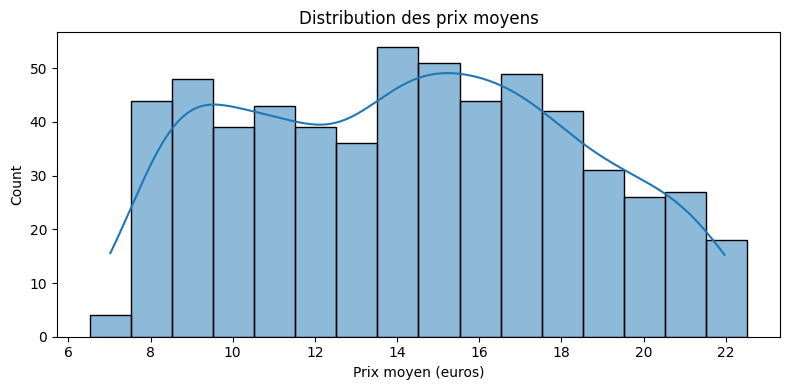

In [11]:
# Visualisation 1 : Distribution des prix moyens
# histogramme de prix_moyen
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["prix_moyen"].dropna(), bins=30, kde=True, ax=ax)
ax.set_title("Distribution des prix moyens")
ax.set_xlabel("Prix moyen (euros)")
plt.tight_layout()
plt.show()

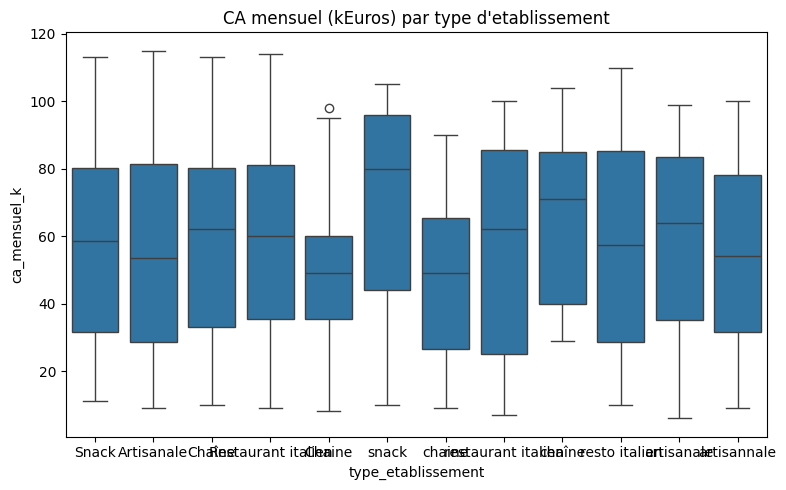

In [12]:
# Visualisation 2 : CA mensuel par type d'etablissement
# boxplot ca_mensuel_k selon type_etablissement
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="type_etablissement", y="ca_mensuel_k", ax=ax)
ax.set_title("CA mensuel (kEuros) par type d'etablissement")
plt.tight_layout()
plt.show()

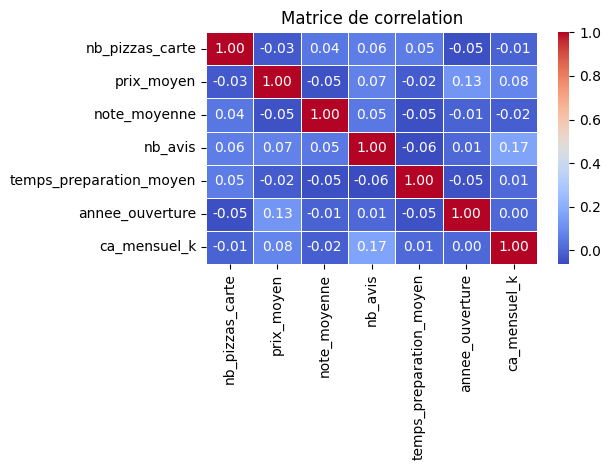

In [13]:
# Visualisation 3 : Matrice de correlation des variables numeriques
num_cols = ["nb_pizzas_carte", "prix_moyen", "note_moyenne",
            "nb_avis", "temps_preparation_moyen", "annee_ouverture", "ca_mensuel_k"]

# convertir proprement les colonnes numeriques (gestion des decimales avec virgule)
corr_data = df[num_cols].copy()
corr_data = corr_data.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

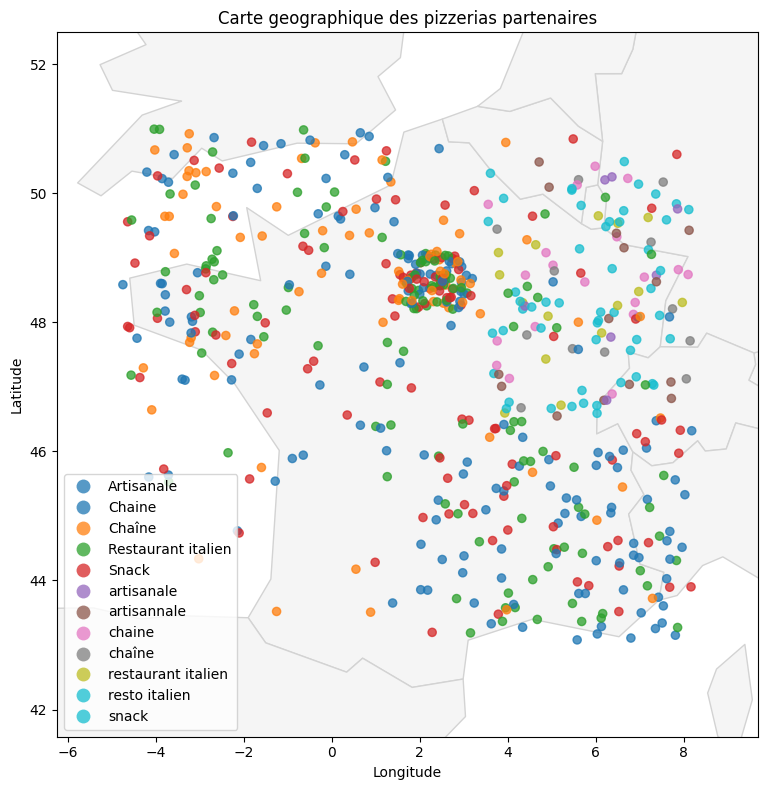

In [14]:
import geopandas as gpd

# Visualisation 4 : Carte geographique "reelle" (fond monde) des etablissements

# 1) Nettoyer/convertir les coordonnees en numerique
df_map = df.copy()
for col in ["latitude", "longitude"]:
    df_map[col] = pd.to_numeric(
        df_map[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

df_map = df_map.dropna(subset=["latitude", "longitude"])

# 2) Creer un GeoDataFrame de points
gdf_points = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["longitude"], df_map["latitude"]),
    crs="EPSG:4326"
)

# 3) Charger la carte du monde et afficher uniquement la zone des donnees
WORLD_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(WORLD_URL).to_crs("EPSG:4326")

pad = 1.5
xmin, ymin, xmax, ymax = gdf_points.total_bounds
xlim = (xmin - pad, xmax + pad)
ylim = (ymin - pad, ymax + pad)

fig, ax = plt.subplots(figsize=(10, 8))
world.plot(ax=ax, color="whitesmoke", edgecolor="lightgray")
gdf_points.plot(
    ax=ax,
    column="type_etablissement",
    categorical=True,
    legend=True,
    markersize=35,
    alpha=0.75
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_title("Carte geographique des pizzerias partenaires")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## 4. Preparation des donnees pour le ML

In [15]:
# Features numeriques pour le clustering
features = [
    "nb_pizzas_carte", "prix_moyen", "note_moyenne",
    "nb_avis", "temps_preparation_moyen", "annee_ouverture", "ca_mensuel_k"
]

X = df[features].copy()

In [16]:
# TODO : imputer les valeurs manquantes
# utiliser la mediane pour ces features
X_numeric = X.apply(
	lambda col: pd.to_numeric(
		col.astype(str).str.replace(",", ".", regex=False),
		errors="coerce"
	)
)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_numeric)

In [17]:
# Standardisation — indispensable pour K-Means (sensible aux echelles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

---
## 5. Clustering K-Means (k=2)

In [18]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Repartition des clusters :")
print(df["cluster"].value_counts())

Repartition des clusters :
cluster
1    326
0    274
Name: count, dtype: int64


In [19]:
# Caracteristiques moyennes de chaque cluster
cluster_means = (
	df.assign(
		**{
			col: pd.to_numeric(
				df[col].astype(str).str.replace(",", ".", regex=False),
				errors="coerce",
			)
			for col in features
		}
	)
	.groupby("cluster")[features]
	.mean()
	.round(2)
)

cluster_means

,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
cluster,,,,,,,
0,30.03,15.40,3.68,1746.28,30.47,2004.51,67.94
1,22.02,13.36,3.81,1191.14,19.01,2003.97,47.98


In [20]:
# repartition des types par cluster
pd.crosstab(df["cluster"], df["type_etablissement"])

type_etablissement,Artisanale,Chaine,Chaîne,Restaurant italien,Snack,artisanale,artisannale,chaine,chaîne,restaurant italien,resto italien,snack
cluster,,,,,,,,,,,,
0,60,17,42,57,49,2,7,9,4,3,9,15
1,69,14,38,71,63,5,7,10,8,12,11,18


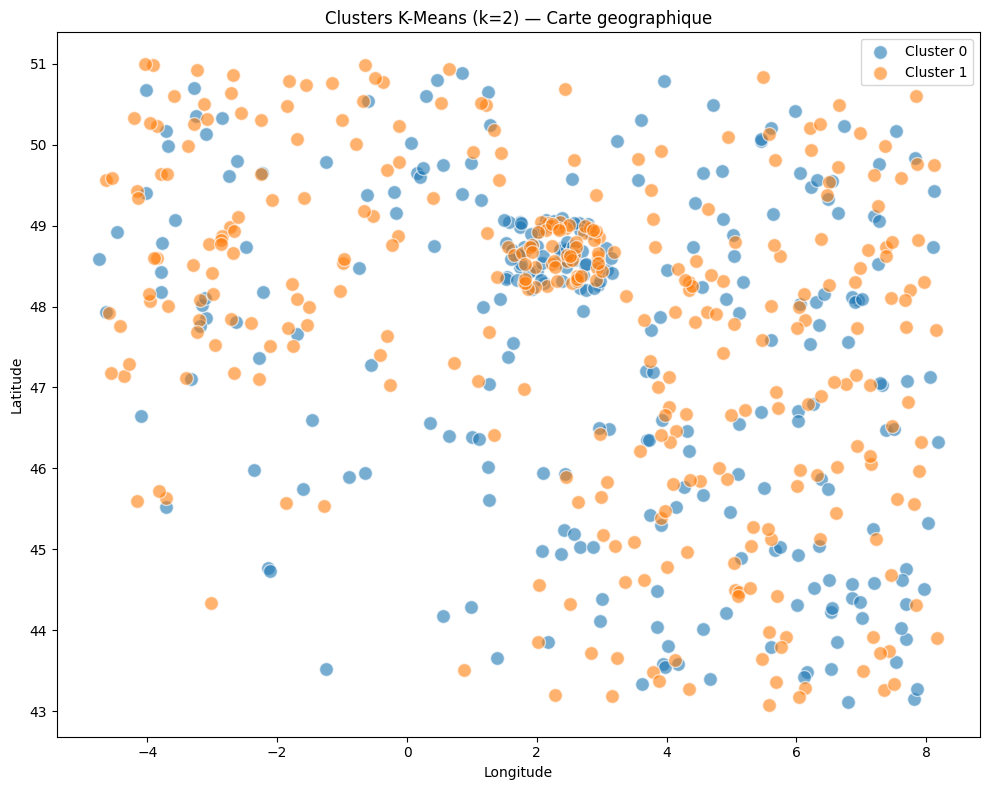

In [21]:
# Carte des clusters
fig, ax = plt.subplots(figsize=(10, 8))
# meme scatter lat/lon, colore par cluster
for c, group in df.groupby("cluster"):
    ax.scatter(group["longitude"], group["latitude"], label=f"Cluster {c}", alpha=0.6, edgecolors="w", s=100)
ax.set_title("Clusters K-Means (k=2) — Carte geographique")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()

### Cluster 0 
Correspond probablement a des etablissements plus haut de gamme (prix moyen plus eleve, note plus elevee, plus d'avis) tandis que le cluster 1 regroupe des etablissements plus basiques ou discount.

### Cluster 1
Correspond probablement a des etablissements plus basiques ou discount (prix moyen plus bas, note plus basse, moins d'avis) tandis que le cluster 0 regroupe des etablissements plus haut de gamme ou a fort volume.


---
## Check ethique — Lignes directrices IA

Un systeme de clustering qui produit des recommandations commerciales doit respecter les principes d'equite, de transparence et de non-discrimination.
Trois verifications concretes a mener sur nos resultats.

### Verification 1 — Biais geographique

Si les clusters suivent la geographie plutot que le profil commercial, le modele ne segmente pas par qualite d'etablissement mais par localisation.

In [22]:
# Position geographique moyenne par cluster
geo_means = (
	df.assign(
		latitude=pd.to_numeric(df["latitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"),
		longitude=pd.to_numeric(df["longitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"),
	)
	.groupby("cluster")[["latitude", "longitude"]]
	.mean()
	.round(3)
)

print(geo_means)

         latitude  longitude
cluster                     
0          47.487      2.927
1          47.767      2.475


 Les deux clusters ont des coordonnées moyennes très proches (Δlat = 0.28°, Δlon = 0.45°, soit environ 30 km). Il n'y a pas de biais géographique détectable — le modèle ne sépare 
  pas Nord vs Sud ni urbain vs rural. 

### Verification 2 — Equite envers les etablissements recents

Les etablissements recents ont peu ou pas d'avis. Leur `note_moyenne` a ete imputee artificiellement. Tombent-ils systematiquement dans le meme cluster ?

In [23]:
# Annee d'ouverture moyenne par cluster
print(df.groupby("cluster")["annee_ouverture"].mean().round(1))

# Proportion d'etablissements ouverts apres 2020 dans chaque cluster
print(df[df["annee_ouverture"] >= 2020].groupby("cluster").size())

cluster
0    2004.5
1    2004.0
Name: annee_ouverture, dtype: float64
cluster
0    32
1    42
dtype: int64


### Verification 3 — Transparence du modele

Les gerants de pizzerias concernes par ce clustering pourraient demander : *"Pourquoi suis-je dans ce groupe ?"*
Les centroides revelent quelles features ont le plus influence la separation.

In [24]:
# Valeurs des centroides dans l'espace original (apres inverse_transform)
centroides_originaux = scaler.inverse_transform(kmeans.cluster_centers_)
pd.DataFrame(centroides_originaux, columns=features, index=["Cluster 0", "Cluster 1"]).round(2)

,nb_pizzas_carte,prix_moyen,note_moyenne,nb_avis,temps_preparation_moyen,annee_ouverture,ca_mensuel_k
Cluster 0,30.03,15.38,3.70,1746.28,30.17,2004.51,67.91
Cluster 1,22.02,13.36,3.81,1191.14,19.40,2003.97,47.98


 Les features qui pilotent le plus la séparation sont le CA (+42%), le nombre d'avis (+47%) et le temps de préparation (+55%). La note_moyenne est quasi identique (3.70 vs 3.81), 
  ce qui confirme que le modèle segmente par volume d'activité, pas par qualité. Ces critères sont explicables et justifiables auprès d'un gérant.